### Duel output UNet on pennate diatoms - separating overlapping cells
### Rayna Hamilton
### April 3, 2025

We will have trained a UNet neural network to detect the locations of pennate diatom cells in strained microscopy images in train_unet.ipynb.  We noted in assess_unet.ipynb that intersecting and overlapping cells are currently considered as a single object, so let's see if we can separate this.  I am going to simply leverage the long, skinny cell shape and try to find the longest lines spanning a segmentation, then separate out the pixels which are contained within each line.

In [ ]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
# %matplotlib inline

from skimage.io import imread, imshow
import os
import math
from math import sqrt
import cv2

In [2]:
images=[]
image_names=[]
input_folder="../../predictions/masks/"
for file in os.listdir(input_folder):
    if file.endswith(".jpg"):
        images.append(imread(f"{input_folder}/{file}"))
        image_names.append(file)
        images[-1]=images[-1]/255


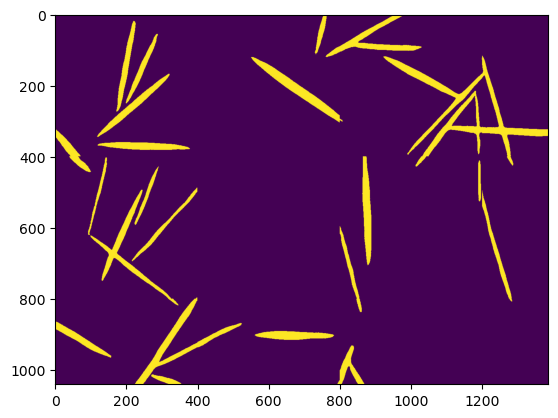

In [3]:
plt.imshow(images[0])

I actually have two functions below to separate out similar looking lines in an image - one compares the start/end points and slopes while the other compares the number of pixels shared.  This is necessary because the latter approach is more useful for our purposes, but is also very inefficient and doesn't complete in a reasonable amount of time with the number of lines generally found.  As such the slope and start/end point comparison is first used to narrow down the list.

In [4]:
def remove_overlapping_lines(lines,slope_threshold=0.2,distance_threshold=4):
    '''
    For an array of line coordinates, finds pairs of lines with start or end points within distance_threshold of each otehr and slopes within slope_threshold of each other, then removes the shorter line.
    '''
    line_slopes=[]
    for i,line in enumerate(lines):
        x11,y11,x12,y12=line
        if x11>x12:
                x11,y11,x12,y12=x12,y12,x11,y11
        lines[i]=x11,y11,x12,y12
        line_slopes.append((line[3]-line[1])/(line[2]-line[0])) 
    
    indices_to_remove=[]
    overlap_found=True
    while overlap_found:
        overlap_found=False
        for i,slope1 in enumerate(line_slopes):
            for j,slope2 in enumerate(line_slopes):
                if (i not in indices_to_remove and j not in indices_to_remove) and i<j:
                    if abs(slope2-slope1)<=slope_threshold: #examine pairs of lines with slopes within slope threshold
                        line1,line2=lines[i],lines[j]
                        x11,y11,x12,y12=line1 #first x coordinate, first y coordinate, second x coordinate, second y coordinate of line 1
                        x21,y21,x22,y22=line2 #first x coordinate, first y coordinate, second x coordinate, second y coordinate of line 2
                        if (sqrt((x11-x21)**2+(y11-y21)**2)<=distance_threshold) or (sqrt((x11-x22)**2+(y11-y22)**2)<=distance_threshold) or (sqrt((x12-x21)**2+(y12-y21)**2)<=distance_threshold) or (sqrt((x12-x22)**2+(y12-y22)**2)<=distance_threshold):
                            #Keep longer line:
                            overlap_found=True
                            if sqrt((x11-x12)**2 + (y11-y12)**2) > sqrt((x21-x22)**2 + (y21-y22)**2):
                                indices_to_remove.append(j)
                            else:
                                indices_to_remove.append(i)
    new_lines=[]
    for i,line in enumerate(lines):
        if i not in indices_to_remove:
            x1,y1,x2,y2=line
            new_lines.append(line)
    print(f"Removed {len(set(indices_to_remove))} very similar lines.")
    return new_lines

In [5]:
def remove_intersecting_lines(lines,coordinates,slope_threshold=0.2,distance_threshold=4):
    '''
    For an array of line coordinates, repeatedly looks for lines with large numbers of overlapping pixels and removes the smaller line.
    '''
    indices_to_remove=[]
    overlap_found=True
    while overlap_found:
        overlap_found=False
        for i,line1 in enumerate(lines):
            for j,line2 in enumerate(lines):
                if (i not in indices_to_remove and j not in indices_to_remove) and i<j:
                    imagei,imagej=np.zeros((1040,1388)),np.zeros((1040,1388))
                    x11,y11,x12,y12=line1 #first x coordinate, first y coordinate, second x coordinate, second y coordinate of line 1
                    x21,y21,x22,y22=line2 #first x coordinate, first y coordinate, second x coordinate, second y coordinate of line 2
                    cv2.line(imagei,(x11,y11),(x12,y12),255,20)
                    i_coordinates=[]
                    for y,x in zip(*np.nonzero(imagei)):
                        if f"{x},{y}" in coordinates.keys():
                            i_coordinates.append(f"{x},{y}")
                    cv2.line(imagej,(x21,y21),(x22,y22),255,20)
                    j_coordinates=[]
                    for y,x in zip(*np.nonzero(imagej)):
                        if f"{x},{y}" in coordinates.keys():
                            j_coordinates.append(f"{x},{y}")
                    intersection=[val for val in i_coordinates if val in j_coordinates]
                    #print(len(i_coordinates),len(j_coordinates))
                    if len(i_coordinates)<200:
                        indices_to_remove.append(i)
                        continue
                    if len(j_coordinates)<200:
                        indices_to_remove.append(j)
                        continue
                        
                    if len(intersection)/len(i_coordinates)>0.4 or len(intersection)/len(j_coordinates)>0.4:
                        overlap_found=True
                        if sqrt((x11-x12)**2 + (y11-y12)**2) > sqrt((x21-x22)**2 + (y21-y22)**2):
                            indices_to_remove.append(j)
                        else:
                            indices_to_remove.append(i)

    new_lines=[]
    for i,line in enumerate(lines):
        if i not in indices_to_remove:
            x1,y1,x2,y2=line
            new_lines.append(line)
    print(f"Removed {len(set(indices_to_remove))} very similar lines.")
    return new_lines

In [6]:
def get_pixels_from_line(line):
    '''
    Returns all pixels spanned by a line with specified start and end points.
    '''
    imagei=np.zeros((1388,1388))
    x1,y1,x2,y2=line
    cv2.line(imagei,(x1,y1),(x2,y2),255,20) 
    i_coordinates=dict()
    max_x,max_y=0,0
    for y,x in zip(*np.nonzero(imagei)):
        i_coordinates[f"{x},{y}"]=""
        if x>max_x:
            max_x=x
        if y>max_y:
            max_y=y
    return i_coordinates

In [7]:
def get_overlap_proportion(line,coordinates):
    '''
    Determines the proportion of a segmentation mask that is covered by a given line.
    '''
    imagei=np.zeros((1040,1388))
    x1,y1,x2,y2=line
    cv2.line(imagei,(x1,y1),(x2,y2),255,20)
    #if abs(slope2-slope1)<=slope_threshold: 
    i_coordinates=[]
    for y,x in zip(*np.nonzero(imagei)):
        if f"{x},{y}" in coordinates.keys():
            i_coordinates.append(f"{x},{y}")
    return len(i_coordinates)/len(coordinates)
                        

In [8]:
def get_distance(coordinates1,coordinates2):
    '''
    Returns the distance between two coordinates in 2d space.
    '''
    x1,y1,x2,y2=int(coordinates1.split(",")[0]),int(coordinates1.split(",")[1]),int(coordinates2.split(",")[0]),int(coordinates2.split(",")[1])
    return math.sqrt(((y2-y1)**2)+((x2-x1)**2))

def check_line_fill(coordinates,x1,y1,x2,y2):
    '''
    Similar to get_overlap_proportion, but models lines as single pixel width.  This is a bit faster and thus used to round down the initial large set
    '''
    if x1>x2:
        x1,y1,x2,y2=x2,y2,x1,y1
    slope=(y2-y1)/(x2-x1)
    current_x,current_y=x1,y1
    total_steps,matching_steps=0,0
    while current_x<=x2:
        
        if f"{int(current_x)},{int(current_y)}" in coordinates.keys():
            matching_steps+=1
        total_steps+=1
        current_x,current_y=current_x+1,current_y+slope
    return matching_steps/total_steps
    
def get_blobs(array):
    '''
    From assess_unet.ipynb - Finds all non-overlapping objects (blobs) within a segmentation mask, and returns an image with each blob as a different colour.
    '''
    segmented_cells=np.zeros((1040,1388,3), dtype=np.uint8)
    coordinates_to_blobs=dict()
    current_blob=-1
    clean_array=np.copy(array)
    blob_sizes=[]
    for i in range(0,len(array)):
        for j in range(0,len(array[i])):    
            if array[i,j]==1 and f"{i},{j}" not in coordinates_to_blobs.keys():
                red,green,blue=np.random.randint(50,255),np.random.randint(50,255),np.random.randint(50,255)
                #start a new blob
                current_blob+=1
                coordinates_to_check=[f"{i},{j}"]
                x,y=i,j
                while True:#expand outwards from current pixel position in all directions until no more filled coordinates are found
                    segmented_cells[x,y,0]=red
                    segmented_cells[x,y,1]=green
                    segmented_cells[x,y,2]=blue
                    coordinates_to_blobs[f"{x},{y}"]=current_blob
                    #check all four surrounding pixels
                    if x>0 and array[x-1,y]>0 and f"{x-1},{y}" not in coordinates_to_blobs.keys():
                        coordinates_to_check.append(f"{x-1},{y}")
                    if x<len(array)-1 and array[x+1,y]>0 and f"{x+1},{y}" not in coordinates_to_blobs.keys():
                        coordinates_to_check.append(f"{x+1},{y}")
                    if y>0 and array[x,y-1]>0 and f"{x},{y-1}" not in coordinates_to_blobs.keys():
                        coordinates_to_check.append(f"{x},{y-1}")
                    if y<len(array[0])-1 and array[x,y+1]>0 and f"{x},{y+1}" not in coordinates_to_blobs.keys():
                        coordinates_to_check.append(f"{x},{y+1}")
                    x=int(coordinates_to_check[-1].split(",")[0])
                    y=int(coordinates_to_check[-1].split(",")[1])
                    coordinates_to_check=coordinates_to_check[:-1]
                    if len(coordinates_to_check)==0:
                        blob_sizes.append(sum([val==current_blob for val in list(coordinates_to_blobs.values())]))
                        break
    return coordinates_to_blobs,blob_sizes,segmented_cells
    
def separate_single_from_multi_cell(image,coordinates_to_blobs,min_line_length=150,min_overlap_proportion=0.8,pixel_step_size=5):
    '''
    For each unique blob in a segmentation, tries to find the single longest line within a blob by combining pairs of start end end coordinates from the edges of the blob.
    If the longest line has substantial pixel overlap with the blob, assume that this is a single-cell blob and return the blob unaltered.
    Otherwise, assume that the blob is multi-cell and:
        - Find all possible lines within a blob passing an overlap and line length threshold
        - Filter down this line list using remove_overlapping_lines and remove_intersecting_lines
        - Separate the blob regions based on whether they intersect with each of the final non-redundant lines, and remove all regions spanned by multiple lines
    '''
    coordinates_to_keep=dict()
    annotated_image=np.copy(image)
    single_cell_image=np.zeros(image.shape)
    blobs_to_keep=list(set(coordinates_to_blobs.values()))
    
    cell_number=0
    for blob in blobs_to_keep:
        coordinates={coordinate:"" for coordinate,blob1 in coordinates_to_blobs.items() if blob1==blob}
        longest_line_coordinates=["",""]
        longest_line=-1
        coordinates_to_check=dict()

        #get just candidate coordinates on the edges of the blob to reduce redundant computations
        for coordinate in coordinates.keys():
            x,y=int(coordinate.split(",")[0]),int(coordinate.split(",")[1])
            if f"{x-1},{y}" not in coordinates.keys() or f"{x+1},{y}" not in coordinates.keys() or f"{x},{y-1}" not in coordinates.keys()  or f"{x},{y+1}" not in coordinates.keys():
                coordinates_to_check[coordinate]=""
                
        for coordinate1 in coordinates_to_check.keys():
            for coordinate2 in coordinates_to_check.keys():
                if coordinate1!=coordinate2:
                    line_length=get_distance(coordinate1,coordinate2)
                    if line_length>=min_line_length and line_length>longest_line:
                        
                        longest_line=line_length
                        longest_line_coordinates=[coordinate1,coordinate2]
        print()
        coordinates1,coordinates2=longest_line_coordinates[0],longest_line_coordinates[1]
        if coordinates1=="":
            for coordinate in coordinates:
                coordinates_to_keep[coordinate]=cell_number
            cell_number+=1
            continue
        x1,y1,x2,y2=int(coordinates1.split(",")[0]),int(coordinates1.split(",")[1]),int(coordinates2.split(",")[0]),int(coordinates2.split(",")[1])
        
        print(longest_line)
        print(longest_line_coordinates)
        #overlap_proportion=check_line_fill(coordinates,x1,y1,x2,y2)
        overlap_proportion=get_overlap_proportion([x1,y1,x2,y2],coordinates)
        print(overlap_proportion)
        
        if overlap_proportion>=min_overlap_proportion:
            cv2.line(annotated_image,(y1,x1),(y2,x2),(255,255,255),20)
            for coordinate in coordinates.keys():
                x,y=int(coordinate.split(",")[0]),int(coordinate.split(",")[1])
                single_cell_image[x,y]=1
                coordinates_to_keep[coordinate]=cell_number
            cell_number+=1
        else:#likely a multicell blob, so find all lines then remove redundant lines
            print("Likely multi-cell blob")
            all_lines=[]
            
            for coordinate1 in coordinates_to_check.keys():
                for coordinate2 in coordinates_to_check.keys():
                    if coordinate1!=coordinate2:
                        line_length=get_distance(coordinate1,coordinate2)
                        
                        if line_length>=min_line_length:
                            x1,y1,x2,y2=int(coordinate1.split(",")[0]),int(coordinate1.split(",")[1]),int(coordinate2.split(",")[0]),int(coordinate2.split(",")[1])
                            if x1!=x2 and (x1%pixel_step_size+x2%pixel_step_size+y1%pixel_step_size+y2%pixel_step_size)==0:
                                
                                overlap_proportion=check_line_fill(coordinates,x1,y1,x2,y2)
                                if overlap_proportion>=min_overlap_proportion:
                                    all_lines.append([x1,y1,x2,y2])
                                    
            print(len(all_lines))
            all_lines=remove_overlapping_lines(all_lines,slope_threshold=0.5,distance_threshold=30)
            unique_lines=remove_intersecting_lines(all_lines,coordinates,slope_threshold=0.5,distance_threshold=1000)

            blacklist_coordinates=dict()
            coordinates_to_lines=dict()
            for k,line1 in enumerate(unique_lines):
                line1_coordinates=get_pixels_from_line(line1)
                for coordinate in line1_coordinates:
                    coordinates_to_lines[coordinate]=k+cell_number
                for line2 in unique_lines:
                    if line1!=line2:
                        line2_coordinates=get_pixels_from_line(line2)
                        for coordinate in line1_coordinates.keys():
                            if coordinate in line2_coordinates.keys():
                                blacklist_coordinates[coordinate]=""
            for coordinate in coordinates:
                if coordinate in coordinates_to_lines.keys() and coordinate not in blacklist_coordinates.keys():
                    coordinates_to_keep[coordinate]=coordinates_to_lines[coordinate]
            for line in unique_lines:
                x1,y1,x2,y2=line
                cv2.line(annotated_image,(y1,x1),(y2,x2),(255,255,255),20)
            print(len(unique_lines))
            print(unique_lines)
            cell_number=cell_number+len(unique_lines)
    print(cell_number)        
    return annotated_image,single_cell_image,coordinates_to_keep

In [9]:
coordinates_to_blobs,blob_sizes,blob_visualization=get_blobs(images[0])    
annotated_image,single_cell_image,coordinates_to_keep=separate_single_from_multi_cell(images[0],coordinates_to_blobs,min_line_length=100,min_overlap_proportion=0.9)


116.21101496846157
['0,763', '112,732']
0.9883959044368601

272.3416971379888
['93,1031', '120,760']
0.2683755404570723
Likely multi-cell blob
272
Removed 242 very similar lines.
Removed 28 very similar lines.
2
[(0, 980, 120, 760), (90, 800, 95, 1025)]

259.8557292037257
['274,173', '19,223']
0.9939853556485355

214.35018077902336
['56,289', '251,200']
0.9960826210826211

514.8057886232439
['119,923', '342,1387']
0.09290626298056953
Likely multi-cell blob
1448
Removed 1395 very similar lines.
Removed 50 very similar lines.
3
[(125, 925, 245, 1140), (150, 1215, 390, 995), (225, 1185, 420, 1015)]

316.48380685273617
['121,551', '300,812']
0.8548986003998857
Likely multi-cell blob
386
Removed 384 very similar lines.
Removed 1 very similar lines.
1
[(120, 555, 290, 800)]

269.98703672583986
['168,321', '346,118']
0.9957033016734509

159.02201105507376
['443,103', '321,1']
0.6677751912204856
Likely multi-cell blob
38
Removed 37 very similar lines.
Removed 0 very similar lines.
1
[(325, 0,

In [11]:
def plot_blobs(coordinates):
    '''
    From coordinates of unique cells returned by separate_single_from_multi_cell, plot the segmentation with each cell as its own color.
    '''
    to_plot=np.zeros((1040,1388,3), dtype=np.uint8)
    colours=dict()
    for cell_number in set(coordinates.values()):
        colours[cell_number]=[np.random.randint(50,255),np.random.randint(50,255),np.random.randint(50,255)]
    for coordinate,cell_number in coordinates.items():
        x,y=int(coordinate.split(",")[0]),int(coordinate.split(",")[1])
        red,green,blue=colours[cell_number][0],colours[cell_number][1],colours[cell_number][2]
        to_plot[x,y,0]=red
        to_plot[x,y,1]=green
        to_plot[x,y,2]=blue
    return to_plot

In [12]:
img=plot_blobs(coordinates_to_keep)

{0: [237, 95, 207], 1: [70, 89, 251], 2: [209, 141, 193], 3: [65, 225, 253], 4: [253, 163, 57], 5: [155, 151, 252], 6: [224, 97, 149], 7: [231, 167, 80], 8: [106, 168, 144], 9: [171, 174, 91], 10: [71, 95, 137], 11: [150, 137, 208], 12: [99, 248, 174], 13: [138, 219, 188], 14: [146, 219, 111], 15: [62, 112, 130], 16: [73, 225, 227], 17: [100, 93, 132], 18: [165, 84, 239], 19: [197, 58, 195], 20: [223, 132, 87], 21: [154, 217, 180], 22: [131, 83, 126], 23: [65, 170, 51], 24: [122, 175, 144], 25: [181, 173, 164]}
1039 1286


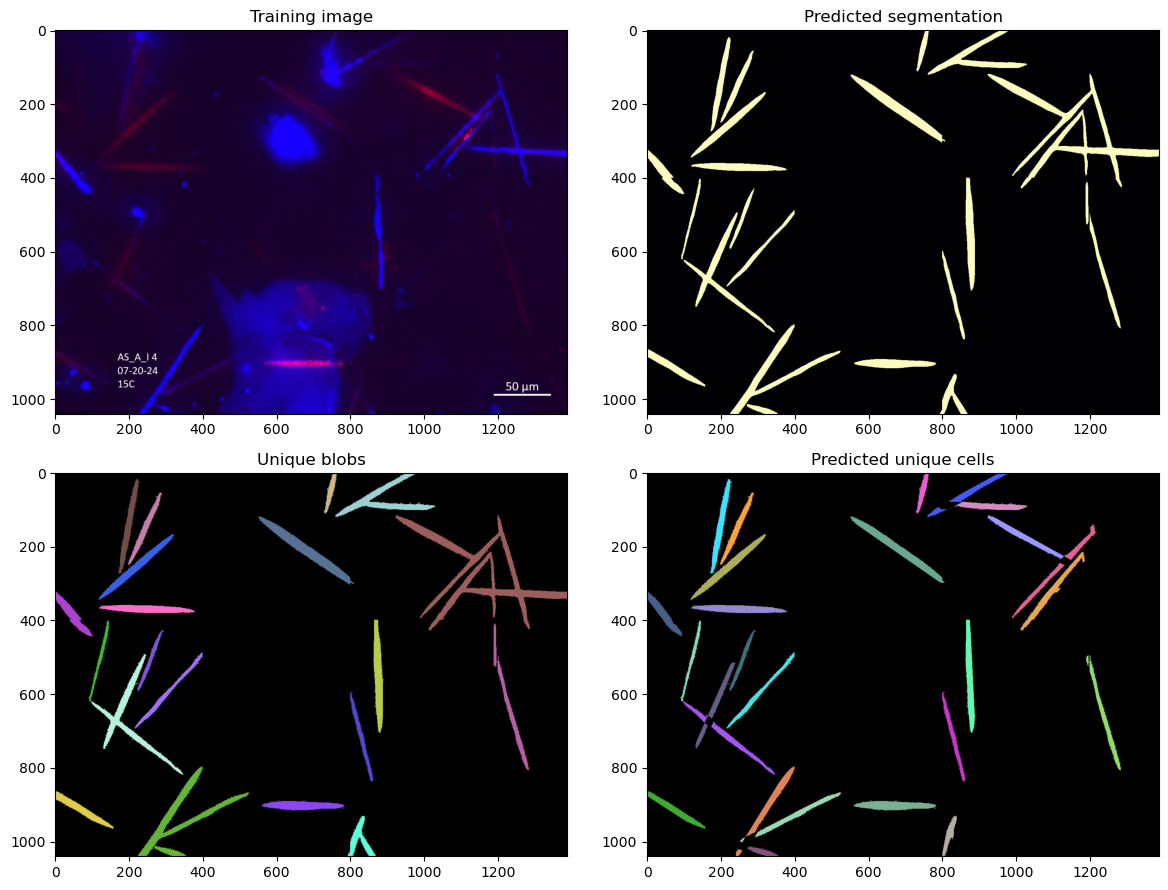

In [24]:
i=0
fig, ax = plt.subplots(2, 2, figsize=(12, 9))
ax[0,0].imshow(imread("../../data/train_images/AS_A_I_15_4-20240720-C28.jpg"), cmap='magma')
ax[0,1].imshow(images[i], cmap='magma')
ax[1,0].imshow(blob_visualization, cmap='magma')
ax[1,1].imshow(img, cmap='magma')
ax[0,0].set_title("Training image")
ax[0,1].set_title("Predicted segmentation")
ax[1,0].set_title("Unique blobs")
ax[1,1].set_title("Predicted unique cells")
fig.tight_layout()

In [26]:
fig.savefig("sample_unique_cells.jpg")

The separation seems to do reasonably well on the images I tested, however there are cases where not all of the cells within a clump are returned.  This is certainly better than low specificity i.e. drawing cells where there are none), but I will still try to improve the performance.  Thankfully, we have a lot of cells to work with in our dataset and there is no reason to believe that clumps are more likely to be infected or uninfected.  As such, missing some of these cells is unlikely to affect the parasite infection rates calculated, which is the ultimate goal of the pipeline.